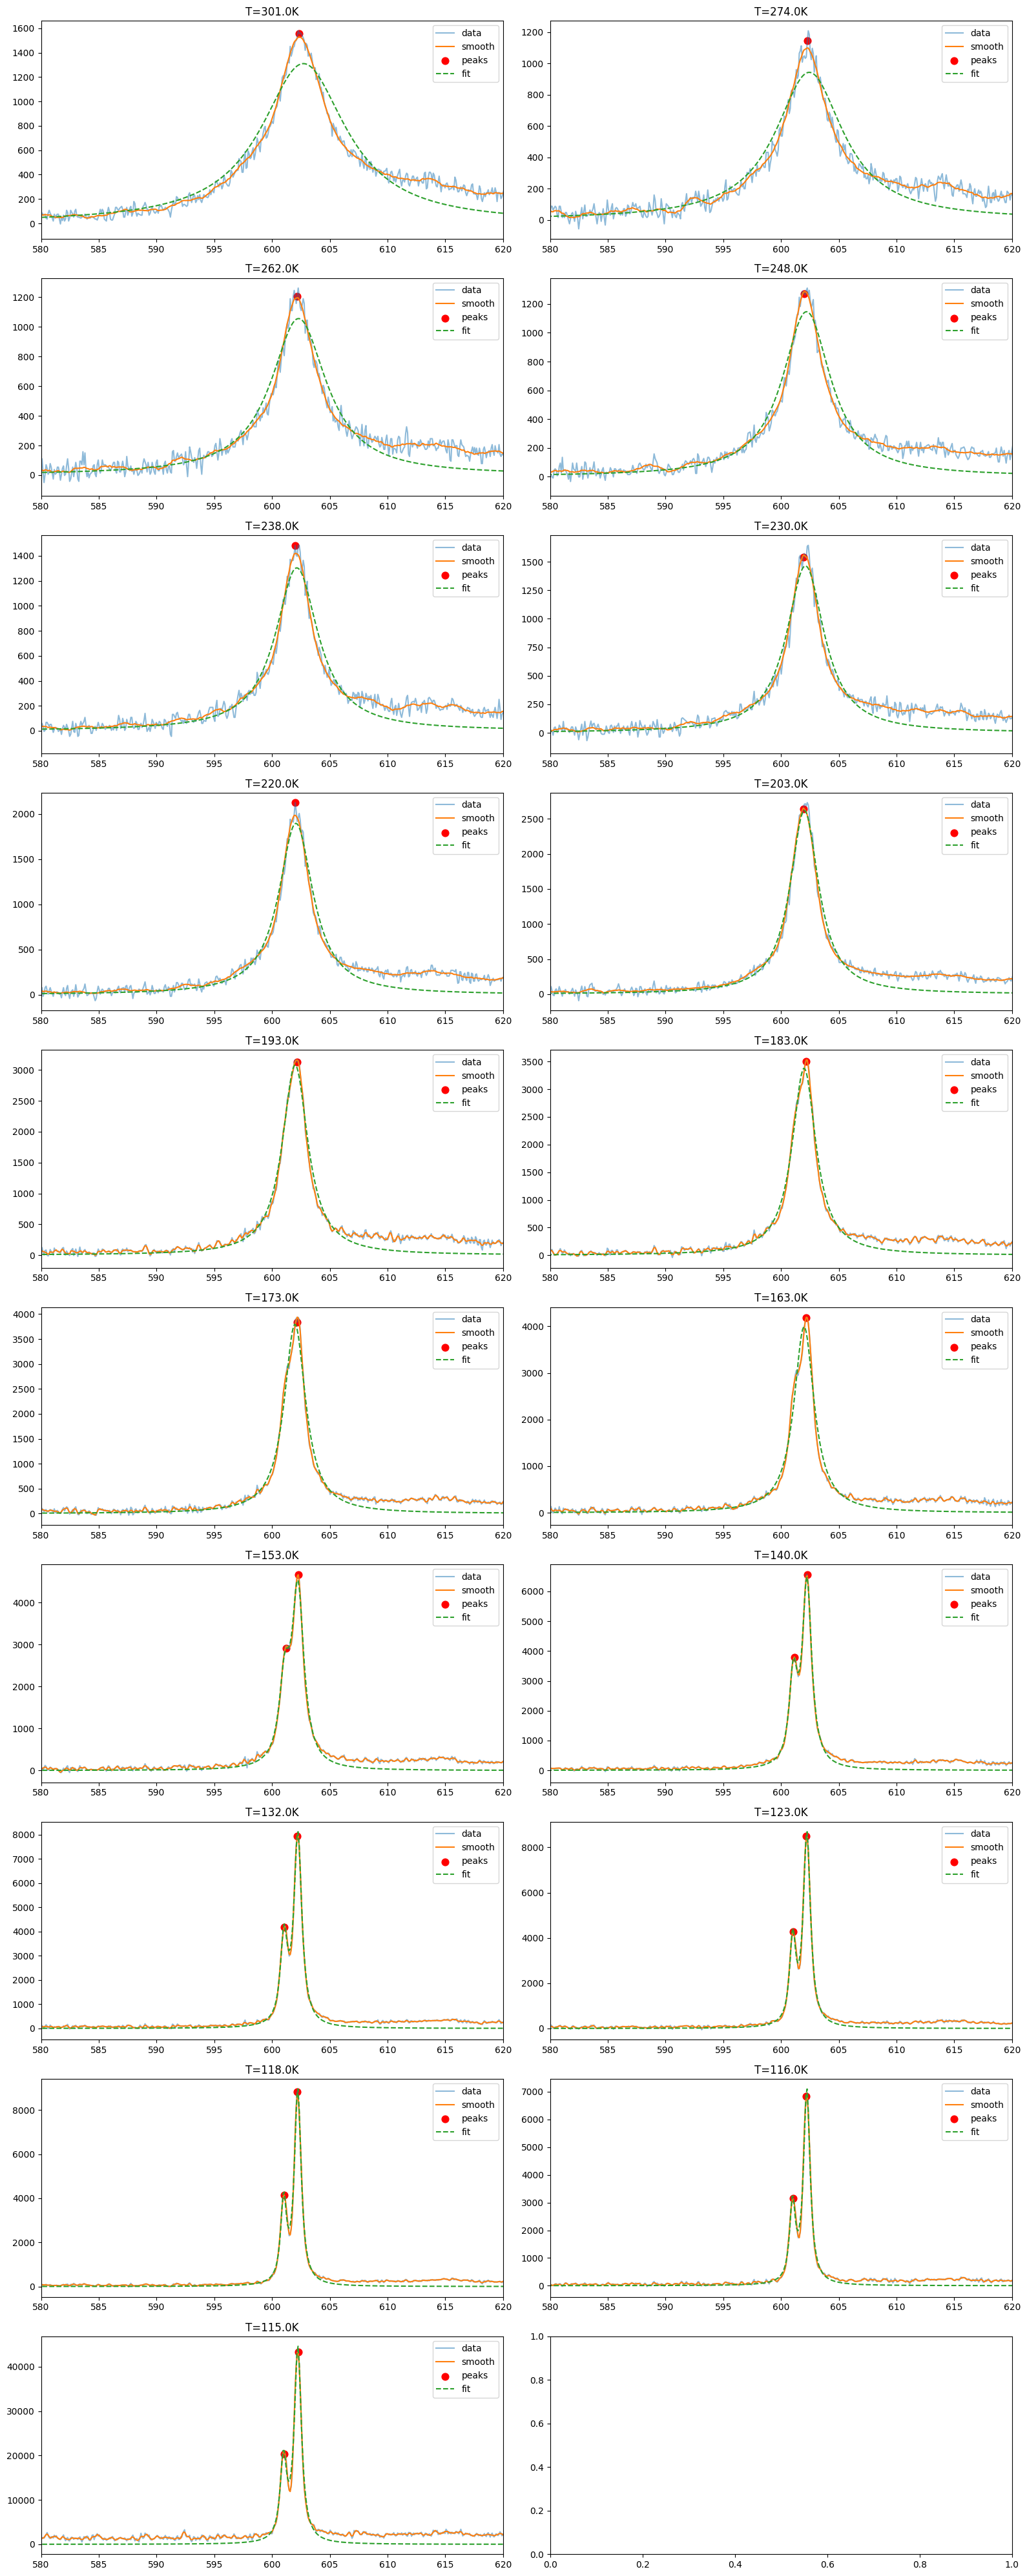


Peak parameters:

      T      center     width     amplitude
0   301  602.721212  4.495613   1310.152238
1   274  602.441412  3.588089    942.668637
2   262  602.299943  2.933778   1056.240002
3   248  602.202818  2.557053   1146.345775
4   238  602.144807  2.253456   1303.348706
5   230  602.108029  1.988494   1463.418933
6   220  602.067437  1.806971   1896.994309
7   203  602.019642  1.509138   2620.708949
8   193  602.002832  1.349029   3080.015991
9   183  601.992033  1.255006   3378.431682
10  173  601.986263  1.134550   3797.951754
11  163  601.991306  1.062854   3991.146352
12  153  602.243727  0.631514   4182.872830
13  153  601.096519  0.565613   1832.656769
14  140  602.244152  0.493307   6158.322136
15  140  601.059627  0.428596   2859.312864
16  132  602.237948  0.415943   7854.721838
17  132  601.032396  0.364639   3465.106058
18  123  602.233880  0.378850   8484.698410
19  123  601.009620  0.322055   3698.298604
20  118  602.229970  0.354326   8799.845908
21  118  601.

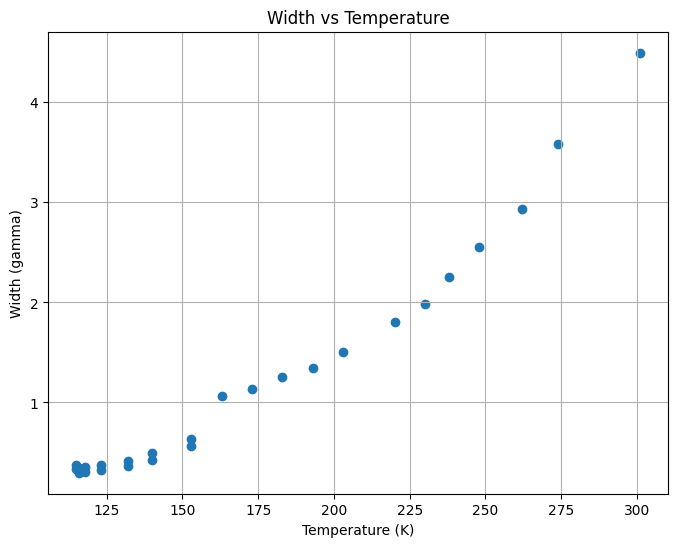

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter


# ============================
# Lorentzian
# ============================

def lorentzian(x, A, x0, gamma):
    return A * gamma**2 / ((x - x0)**2 + gamma**2)


def double_lorentzian(x, A1, x01, g1, A2, x02, g2):
    return (
        lorentzian(x, A1, x01, g1)
        + lorentzian(x, A2, x02, g2)
    )


# ============================
# Measurement class
# ============================

class Measurement:

    def __init__(
        self,
        T,
        fit_range=(550,650),
        peak_height=0.3,
        peak_distance=5,
        smooth_window=31,
        smooth_poly=3
    ):

        self.T = T
        self.data = pd.read_csv(f"parsed_data/data_{-T}.esp", sep=" ")
        self.T = T + 273

        # настройки
        self.fit_range = fit_range
        self.peak_height = peak_height
        self.peak_distance = peak_distance
        self.smooth_window = smooth_window
        self.smooth_poly = smooth_poly

        # обрезка диапазона
        mask = (
            (self.data["lambda"] > fit_range[0]) &
            (self.data["lambda"] < fit_range[1])
        )

        self.data = self.data[mask]

        self.fit_params = None
        self.fit_type = None
        self.peaks = None
        self.y_smooth = None

    # ============================
    # FIT
    # ============================

    def fit(self):

        x = self.data["lambda"].values
        y = self.data["I"].values

        # сглаживание
        y_smooth = savgol_filter(
            y,
            self.smooth_window,
            self.smooth_poly
        )

        self.y_smooth = y_smooth

        # мягкий поиск
        peaks, _ = find_peaks(
            y_smooth,
            distance=self.peak_distance
        )

        # нормировка по максимуму
        threshold = np.max(y) * self.peak_height
        peaks = peaks[y[peaks] > threshold]

        # сортировка
        if len(peaks) > 0:
            order = np.argsort(y[peaks])[::-1]
            peaks = peaks[order]

        self.peaks = peaks

        # ============================
        # double fit
        # ============================

        if len(peaks) >= 2:

            p1 = peaks[0]
            p2 = peaks[1]

            A1 = y[p1]
            x01 = x[p1]

            A2 = y[p2]
            x02 = x[p2]

            gamma0 = 0.5

            try:

                popt, _ = curve_fit(
                    double_lorentzian,
                    x,
                    y,
                    p0=[A1, x01, gamma0, A2, x02, gamma0],
                    maxfev=20000
                )

                self.fit_type = "double"
                self.fit_params = popt

                return

            except:
                pass

        # ============================
        # single fit
        # ============================

        A0 = np.max(y)
        x0 = x[np.argmax(y)]
        gamma0 = 1

        popt, _ = curve_fit(
            lorentzian,
            x,
            y,
            p0=[A0, x0, gamma0],
            maxfev=20000
        )

        self.fit_type = "single"
        self.fit_params = popt


    # ============================
    # параметры пиков
    # ============================

    def get_peak_params(self):

        if self.fit_type == "single":

            A, x0, gamma = self.fit_params

            return [{
                "T": self.T,
                "center": x0,
                "width": gamma,
                "amplitude": A
            }]

        else:

            A1, x01, g1, A2, x02, g2 = self.fit_params

            return [
                {
                    "T": self.T,
                    "center": x01,
                    "width": g1,
                    "amplitude": A1
                },
                {
                    "T": self.T,
                    "center": x02,
                    "width": g2,
                    "amplitude": A2
                }
            ]


    # ============================
    # Plot
    # ============================

    def plot_debug(self, ax, plot_range=None):

        x = self.data["lambda"].values
        y = self.data["I"].values

        ax.plot(x, y, label="data", alpha=0.5)

        if self.y_smooth is not None:
            ax.plot(x, self.y_smooth, label="smooth")

        if self.peaks is not None and len(self.peaks) > 0:

            ax.scatter(
                x[self.peaks],
                y[self.peaks],
                color="red",
                s=60,
                label="peaks"
            )

        if self.fit_params is not None:

            x_fit = np.linspace(x.min(), x.max(), 1000)

            if self.fit_type == "single":
                y_fit = lorentzian(x_fit, *self.fit_params)
            else:
                y_fit = double_lorentzian(x_fit, *self.fit_params)

            ax.plot(x_fit, y_fit, "--", label="fit")

        if plot_range:
            ax.set_xlim(plot_range)

        ax.set_title(f"T={self.T:.1f}K")
        ax.legend()


# ============================
# Temperatures
# ============================

Ts = [
    28, 1, -11, -25, -35, -43, -53,
    -70, -80, -90, -100, -110, -120,
    -133, -141, -150, -155, -157, -158
]


# можно настраивать для каждого измерения
measurements = [
    Measurement(
        T,
        fit_range=(550,650),
        peak_height=0.4,     # удобно крутить
        peak_distance=1,
        smooth_window=7
    )
    for T in Ts
]



# ============================
# FIT
# ============================

for m in measurements:
    if(m.T > 200):
        m.smooth_window = 30
    m.fit()


# ============================
# Plot debug
# ============================

plots_per_fig = 20

for i in range(0, len(measurements), plots_per_fig):

    fig, axs = plt.subplots(10, 2, figsize=(16,40))
    axs = axs.flatten()

    for j in range(plots_per_fig):

        if i+j >= len(measurements):
            break

        measurements[i+j].plot_debug(
            axs[j],
            plot_range=(580,620)
        )

    plt.tight_layout()
    plt.show()


# ============================
# Сбор параметров
# ============================

all_peaks = []

for m in measurements:
    all_peaks += m.get_peak_params()

results = pd.DataFrame(all_peaks)

print("\nPeak parameters:\n")
print(results)

results.to_csv("fit_results.csv", index=False)


# ============================
# Width vs Temperature
# ============================

plt.figure(figsize=(8,6))

plt.scatter(
    results["T"],
    results["width"]
)

plt.xlabel("Temperature (K)")
plt.ylabel("Width (gamma)")
plt.title("Width vs Temperature")

plt.grid()
plt.show()